In [2]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": [], "slos": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, slo, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
            if span == "end_to_end":
                data["slos"].append(int(slo))
    for key in data.keys():
        n_ignore = int(len(data[key]) * ignore)
        data[key] = data[key][n_ignore:]
    return data


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail


def get_slo_vio(data, slo):
    cnt = 0
    for i in range(len(data)):
        if data[i] > slo[i]:
            cnt += 1
    return cnt / len(data) * 100


def get_slo_vio_select(data, slos, select):
    cnt = 0
    for i in range(len(data)):
        if slos[i] != select:
            continue
        if data[i] > slos[i]:
            cnt += 1
    return cnt / len(data) * 100

In [3]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs_1x": [],
    "masa_1x": [],
    "masa_2x": [],
    "masa_4x": [],
    "masa_8x": [],
}

slo1 = int(1e5)
slo2 = slo1 * 2

for rps in rps_values:
    e2e_data["rps"].append(rps)

    file = f"slo-1e5-1x-fcfs/r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs_1x"].append(get_slo_vio(data["end_to_end"], data["slos"]))

    file = f"slo-1e5-1x/r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa_1x"].append(get_slo_vio(data["end_to_end"], data["slos"]))

    file = f"slo-1e5-2x/r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa_2x"].append(get_slo_vio(data["end_to_end"], data["slos"]))

    file = f"slo-1e5-4x/r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa_4x"].append(get_slo_vio(data["end_to_end"], data["slos"]))

    file = f"slo-1e5-8x/r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa_8x"].append(get_slo_vio(data["end_to_end"], data["slos"]))

print(e2e_data)
print()

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs_1x': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.002519748529096796, 0.008233625377530437, 0.03004026745963972, 0.16472752722282838, 0.6365140341530438, 2.1990038921798796, 7.042084091193425, 20.976114903644202, 46.850728678001424, 77.43123300261261, 96.38560994590135, 99.96806528874302, 99.99930127709081], 'masa_1x': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0003742556989786562, 0.0, 0.0036674032034766987, 0.02551664189776519, 0.24358515892635957, 1.8797336181924917, 13.696217658713222, 50.46701680672269, 89.37298828376464, 99.61821826439324, 99.99964516987492, 100.0], 'masa_2x': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.008180077181434112, 0.07435311665352572, 2.068916255950655, 25.95874062849729, 88.34771585978257, 99.99024217156037, 100.0], 'masa_4x': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00021008

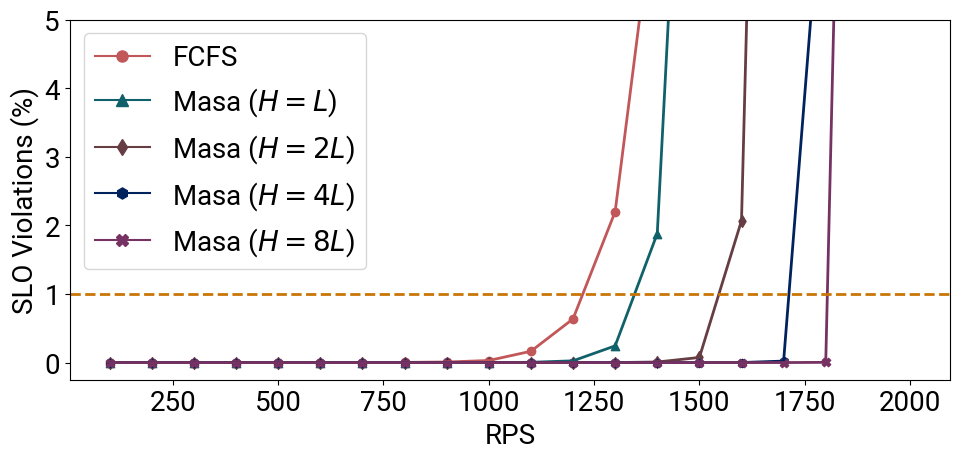

slo: 1, FCFS: 1346, Masa: 1546, Goodput: 115%, Provision: 87%
slo: 5, FCFS: 1426, Masa: 1612, Goodput: 113%, Provision: 88%
slo: 10, FCFS: 1469, Masa: 1633, Goodput: 111%, Provision: 90%


In [34]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    }
)

data = e2e_data

x = np.array(data["rps"])
y0 = np.array(data["fcfs_1x"])
y1 = np.array(data["masa_1x"])
y2 = np.array(data["masa_2x"])
y3 = np.array(data["masa_4x"])
y4 = np.array(data["masa_8x"])
ys = [y0, y1, y2, y3, y4]

markers = ["o", "^", "d", "h", "X"]
colors = ["#C25759", "#11616B", "#653D43", "#00225D", "#763262"]

plt.figure(figsize=(10, 5))

for i in range(len(ys)):
    plt.scatter(
        x,
        ys[i],
        color=colors[i],
        marker=markers[i],
    )
    plt.plot(
        x,
        ys[i],
        color=colors[i],
        linewidth=2,
    )

# draw a horizontal line representing the SLO 1%
plt.axhline(
    y=1,
    color="#CA7508",
    linestyle="--",
    linewidth=2,
    # label="SLO 1%",
)

# plt.title("SLO Violations")
plt.xlabel("RPS")
# plt.xticks(list(range(200, 2001, 200)))
plt.ylabel("SLO Violations (%)")
plt.ylim(-0.25, 5)
plt.yticks(list(range(0, 6, 1)))

elements = [
    plt.Line2D(
        [0], [0], marker=markers[0], color=colors[0], label="FCFS", markersize=8
    ),
    plt.Line2D(
        [0], [0], marker=markers[1], color=colors[1], label="Masa ($H=L$)", markersize=8
    ),
    plt.Line2D(
        [0],
        [0],
        marker=markers[2],
        color=colors[2],
        label="Masa ($H=2L$)",
        markersize=8,
    ),
    plt.Line2D(
        [0],
        [0],
        marker=markers[3],
        color=colors[3],
        label="Masa ($H=4L$)",
        markersize=8,
    ),
    plt.Line2D(
        [0],
        [0],
        marker=markers[4],
        color=colors[4],
        label="Masa ($H=8L$)",
        markersize=8,
    ),
]
plt.tight_layout()
plt.legend(handles=elements, loc="upper left")
plt.savefig("slo_1e5_combo.pdf")
plt.show()


def solve(x, y, slo):
    # Ensure the input lists are of equal length and are not empty
    if len(x) != len(y) or len(x) == 0:
        return None

    # Traverse the list to find the point where y crosses below slo
    for i in range(1, len(y)):
        if y[i - 1] <= slo and y[i] > slo:
            # Linear interpolation
            # Equation of line (y - y1) = ((y2 - y1) / (x2 - x1)) * (x - x1)
            # Solving for x when y = slo:
            # x = x1 + ((slo - y1) / (y2 - y1)) * (x2 - x1)
            if y[i] != y[i - 1]:  # to avoid division by zero
                x_interpolated = x[i - 1] + ((slo - y[i - 1]) / (y[i] - y[i - 1])) * (
                    x[i] - x[i - 1]
                )
                return x_interpolated

    # If no crossing is found or all y-values are below slo
    return None


for slos in [1, 5, 10]:
    x1 = round(solve(x, y1, slos))
    x2 = round(solve(x, y2, slos))
    goodput = x2 / x1 * 100
    provision = x1 / x2 * 100
    print(
        f"slo: {slos}, FCFS: {x1}, Masa: {x2}, Goodput: {round(goodput)}%, Provision: {round(provision)}%"
    )